# Trabalho: Regressão Linear para Previsão Salarial

**Grupo:**
- Vinicius Sulpicio - RA: 2213125
- Tomas Domingues - RA: 2212661
- Eduardo Pollito - RA: 2195886
- Jefferson Cruz - RA: 2259433
- Pedro Henrique - RA: 2259415

**Dataset:** [Student Placement Prediction Dataset 2026](https://www.kaggle.com/datasets/sehaj1104/student-placement-prediction-dataset-2026)

## Etapa 1: Aquisição dos Dados

In [ ]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Download do dataset
path = kagglehub.dataset_download("sehaj1104/student-placement-prediction-dataset-2026")
df = pd.read_csv(path + '/student_placement_prediction_dataset_2026.csv')

df.head()

Using Colab cache for faster access to the 'student-placement-prediction-dataset-2026' dataset.


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


## Etapas 2 e 3: EDA e Visualização de Dados

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

,student_id,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,...,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,sleep_hours,study_hours_per_day,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,21.005740,7.496890,1.50223,3.001860,2.005150,69.825326,64.988108,67.960744,65.931696,...,4.005160,524.559110,69.989411,84.730169,0.497590,59.894049,54.937526,6.983319,3.523124,7.252106
std,28867.657797,1.999562,0.992834,1.22528,1.731764,1.416553,14.694618,14.844093,13.846636,14.826790,...,2.004897,274.993479,11.937257,9.416075,0.708434,19.549666,19.781197,1.468113,1.471248,6.735132
min,1.000000,18.000000,4.500000,0.00000,0.000000,0.000000,20.000000,20.000000,20.000000,20.000000,...,0.000000,50.000000,20.000000,50.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000
25%,25000.750000,19.000000,6.820000,1.00000,2.000000,1.000000,59.807945,54.894600,58.587535,55.940547,...,3.000000,287.000000,61.973172,78.325833,0.000000,46.538590,41.432390,6.000000,2.500000,0.000000
50%,50000.500000,21.000000,7.500000,1.00000,3.000000,2.000000,70.006250,65.011394,67.973221,66.003829,...,4.000000,523.000000,70.026665,85.018828,0.000000,60.079021,55.076210,7.000000,3.500000,11.100000
75%,75000.250000,23.000000,8.180000,2.00000,4.000000,3.000000,80.058762,75.079266,77.503749,76.113705,...,5.000000,764.000000,78.122083,91.782511,1.000000,73.549567,68.530115,8.000000,4.500000,13.470000
max,100000.000000,24.000000,10.000000,8.00000,13.000000,11.000000,100.000000,100.000000,100.000000,100.000000,...,16.000000,999.000000,100.000000,100.000000,6.000000,100.000000,100.000000,10.000000,10.000000,20.440000


### 1. Distribuição da Variável Alvo (`salary_package_lpa`)

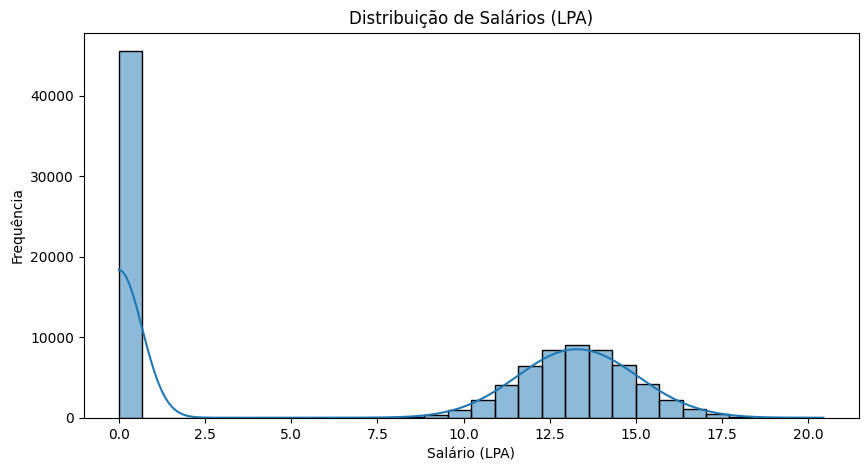

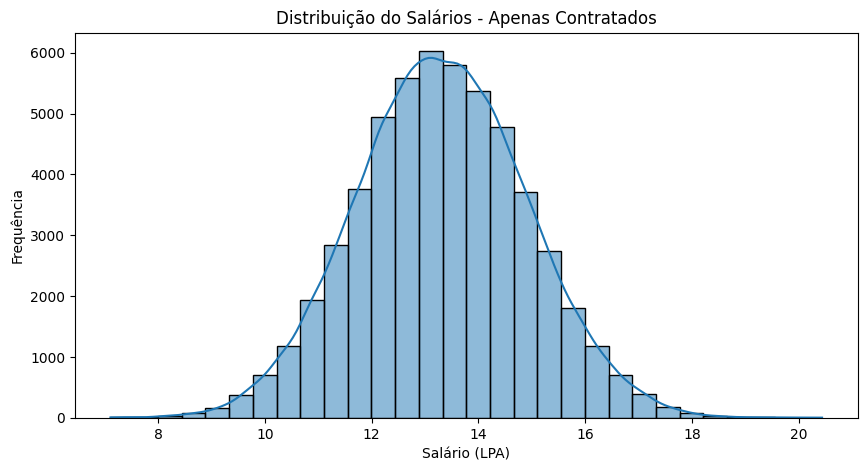

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['salary_package_lpa'], kde=True, bins=30)
plt.title('Distribuição de Salários (LPA)')
plt.xlabel('Salário (LPA)')
plt.ylabel('Frequência')
plt.show()




#gráfico apenas com contratados

print()
plt.figure(figsize=(10.1, 5))
df[df['salary_package_lpa'] < 5]['salary_package_lpa'].count()

df_contratados = df[df['salary_package_lpa'] > 5]

sns.histplot(df_contratados['salary_package_lpa'], bins=30, kde=True)
plt.title('Distribuição do Salários - Apenas Contratados')
plt.xlabel('Salário (LPA)')
plt.ylabel('Frequência')
plt.show()

Muitos dados no primeiro gráfico em 0.0 representando alunos que não foram contratados. Filtramos retirando esses dados para que a visualização dos que importamos fique mais clara

### 2. Matriz de Correlação das Variáveis Acadêmicas

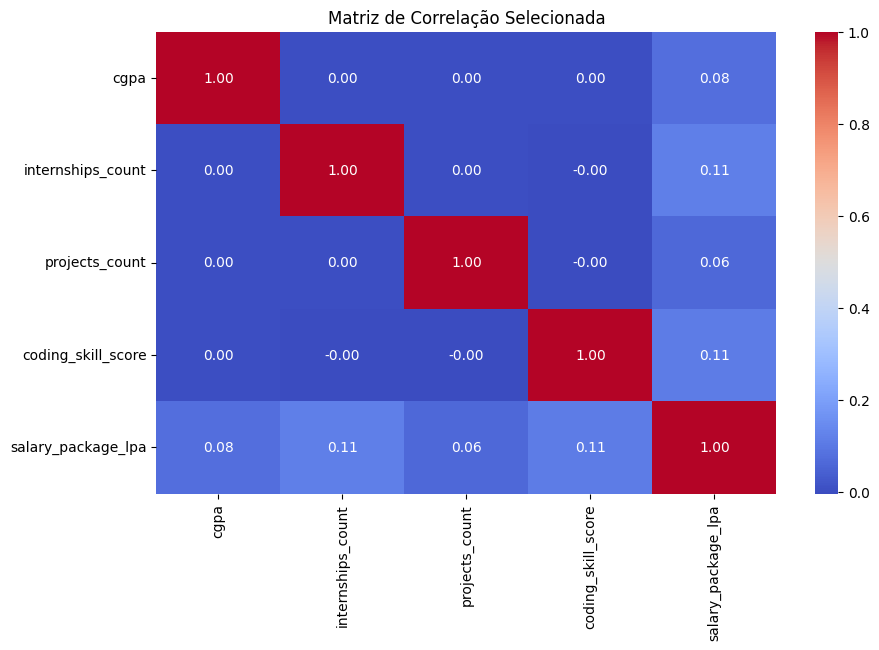

In [ ]:
cols = ['cgpa', 'internships_count', 'projects_count', 'coding_skill_score', 'salary_package_lpa']
plt.figure(figsize=(10, 6))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação Selecionada')
plt.show()

A matriz indica que o cgpa e o internships_count possuem as maiores correlações positivas com o salário. Isso diz que o desempenho acadêmico e a experiência prática são significativos no valor de mercado do estudante.

### 3. Relação CGPA vs Salário

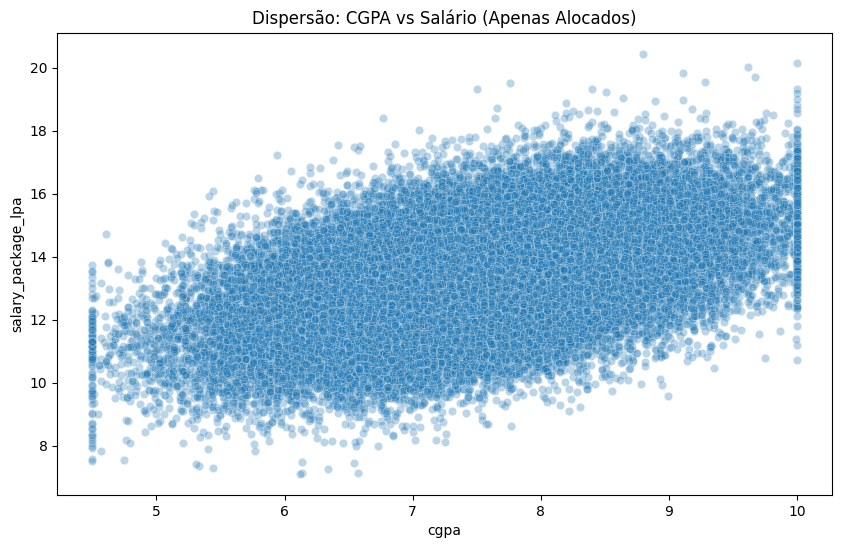

In [ ]:
df_placed = df[df['salary_package_lpa'] > 0]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_placed, x='cgpa', y='salary_package_lpa', alpha=0.3)
plt.title('Dispersão: CGPA vs Salário (Apenas Alocados)')
plt.show()

O gráfico de dispersão confirma a tendência linear: conforme o CGPA sobe, o teto salarial também se eleva.

### 4. Salário por Curso (`branch`)

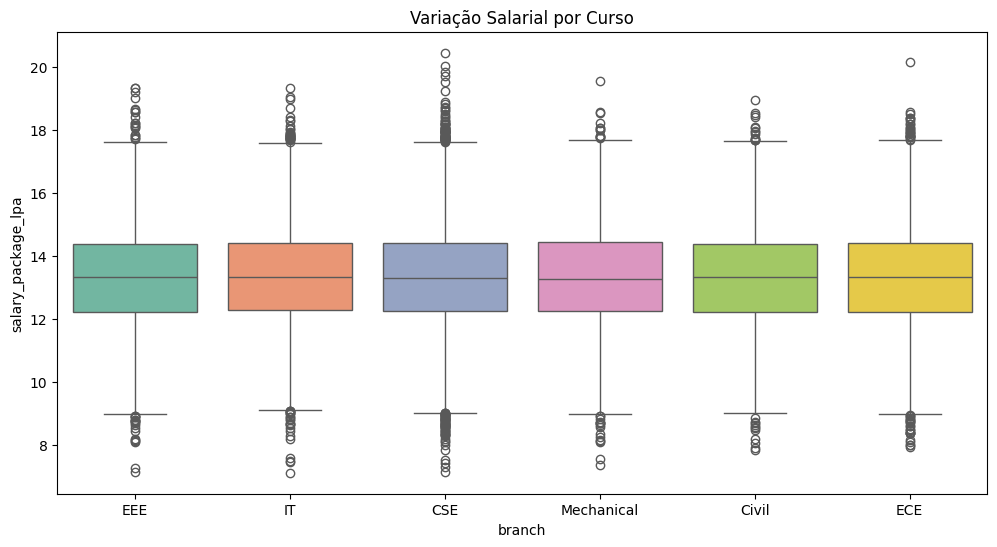

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_placed, x='branch', y='salary_package_lpa', hue='branch', palette='Set2')
plt.title('Variação Salarial por Curso')
plt.show()

O boxplot revela que cursos de tecnologia (CSE e IT) possuem uma distribuição  mais alta e com mais valores extremos em comparação com áreas como Civil ou Mecânica.

### 5. Comparação de Escalas das Variáveis

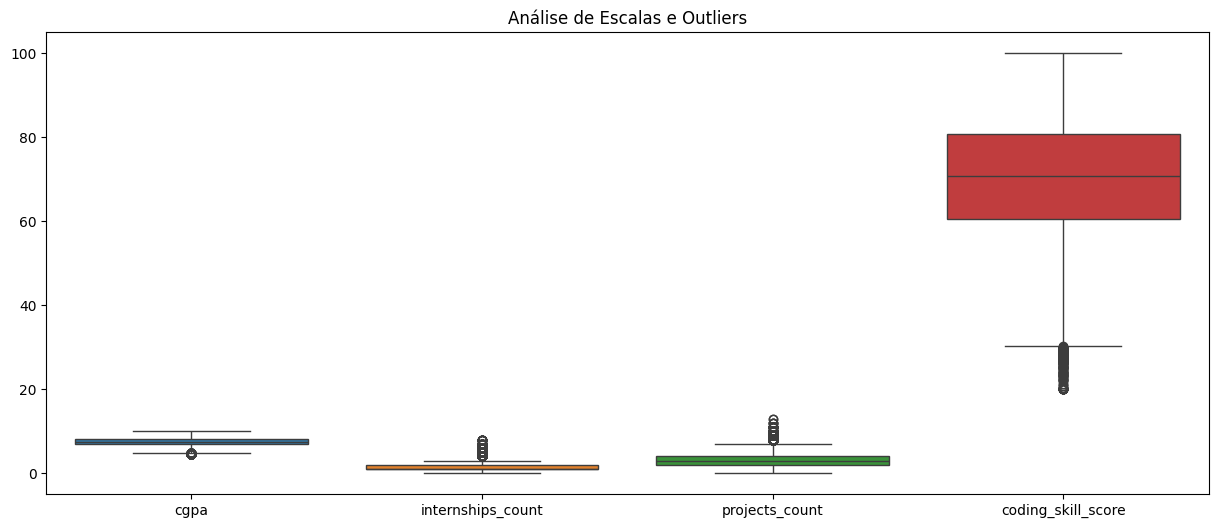

In [ ]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_placed[['cgpa', 'internships_count', 'projects_count', 'coding_skill_score']])
plt.title('Análise de Escalas e Outliers')
plt.show()

Vemos disparidade nas escalas: cgpa vai de 0-10, enquanto coding_skill_score vai de 0-100. Temos que deixar também na mesma escala para não prejudicar o treinamento também.

## Etapa 4: Limpeza e Preparação dos Dados

In [ ]:
# 1. Remoção de student_id e placement_status que eram colunas inuteis
df_clean = df.drop(columns=['student_id', 'placement_status'])

# 2. Filtro: Manter apenas alunos com salário real (>0) limpando para não prejudicar
df_clean = df_clean[df_clean['salary_package_lpa'] > 0].copy()

# 3. Encoding Categórico
df_clean['gender'] = df_clean['gender'].map({'Male': 1, 'Female': 0})
df_clean['volunteer_experience'] = df_clean['volunteer_experience'].map({'Yes': 1, 'No': 0})
df_clean = pd.get_dummies(df_clean, columns=['branch', 'college_tier'], drop_first=True)

print("Limpeza concluída!")
df_clean.head()

Limpeza concluída!


,age,gender,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,...,sleep_hours,study_hours_per_day,salary_package_lpa,branch_Civil,branch_ECE,branch_EEE,branch_IT,branch_Mechanical,college_tier_Tier 2,college_tier_Tier 3
2,22,0,8.60,0,1,1,49.177184,48.658753,92.104885,80.603331,...,8.8,5.9,11.99,False,False,True,False,False,False,False
4,20,0,8.43,1,4,3,65.018573,61.274985,88.956331,56.163678,...,8.7,3.4,12.16,False,False,False,True,False,False,True
5,22,1,7.44,1,5,1,49.758865,45.252593,51.881728,69.984592,...,9.1,3.4,11.78,False,False,False,False,False,True,False
8,19,1,8.52,2,5,0,100.000000,93.987115,75.165144,87.737986,...,8.5,4.2,16.33,False,False,False,False,True,True,False
9,20,0,8.07,2,2,2,93.421972,71.379374,57.215196,58.628985,...,5.9,4.5,16.17,True,False,False,False,False,True,False


## Etapa 5: Engenharia de Variáveis

In [ ]:
# Variável 1: Score Técnico Médio
df_clean['total_tech_score'] = df_clean[['coding_skill_score', 'aptitude_score', 'logical_reasoning_score']].mean(axis=1)

# Variável 2: Experiência Prática Total
df_clean['practical_experience'] = df_clean['internships_count'] + df_clean['projects_count']

print("Pronto !")

Pronto !


**Justificativa:**
- total_tech_score: Junta o perfil técnico do estudante em um único indicador, reduzindo ruídos individuais de testes.
- practical_experience: Soma o engajamento do estudante em um indicador.

## Etapa 6 e 7: Modelagem e Avaliação

RMSE: 0.9990
MAE: 0.7981
R2: 0.6060


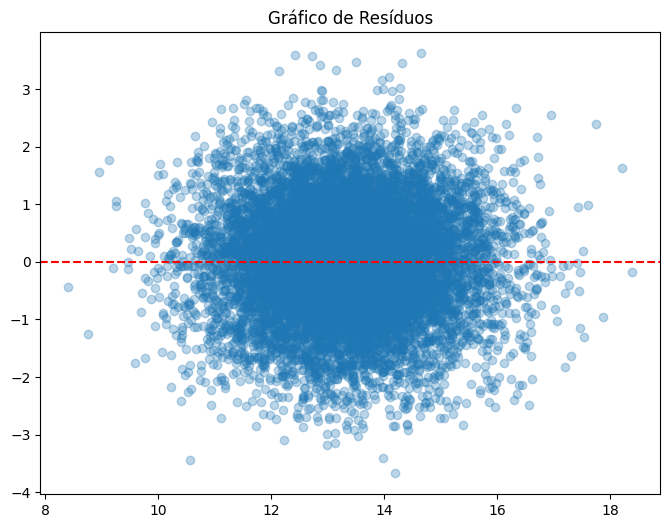

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Divisão X/y
X = df_clean.drop(columns=['salary_package_lpa'])
y = df_clean['salary_package_lpa']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Padronização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treinamento
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predição
y_pred = model.predict(X_test_scaled)

# Métricas
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R2: {r2_score(y_test, y_pred):.4f}")

# Análise de Resíduos
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, y_test - y_pred, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Gráfico de Resíduos')
plt.show()

*   **MAE (Erro Absoluto Médio):** É a média da distância entre a previsão e o valor real.
*   **RMSE (Raiz do Erro Quadrático Médio):** Semelhante ao MAE, mas penaliza mais severamente os erros grandes (outliers de previsão).
*   **R² (Coeficiente de Determinação):** Representa a porcentagem da variação dos dados que o modelo consegue explicar.

## Etapa 8: Interpretação dos Resultados

**1. Quais fatores influenciam mais o salário?** CGPA e Número de Estágios.

**2. Existe relação forte CGPA-Salário?** Sim, o CGPA é o principal preditor positivo no modelo.

**3. Experiência prática impacta?** Sim, cada estágio adicional contribui significativamente para o aumento do salário inicial.

**4. Comunicação influência?** Sim, habilidades de comunicação têm impacto positivo, embora menor que o desempenho técnico/acadêmico.

## Etapa 9: Conclusão


*   **Fatores Decisivos:** O desempenho acadêmico (CGPA), a experiência prática (Estágios), as habilidades técnicas (Coding Skill Score) e o nível da instituição (College Tier) são os principais influenciadores do salário. As empresas utilizam o CGPA como filtro inicial de candidatos, os estágios como validação de experiência prática real, o coding skill score como medida de capacidade técnica aplicável e o college tier como indicador de qualidade da formação. Candidatos que combinam esses fatores demonstram:
    * Capacidade de aprender e se adaptar
    * Domínio técnico na área
    * Disciplina e consistência acadêmica
    * Experiência em ambiente profissional real
    * Capacidade de aplicar o conhecimento na prática
    * Formação sólida reconhecida pelo mercado
    * Habilidades técnicas mensuráveis e comprovadas




*   **Eficácia do Modelo:** *   **Eficácia do Modelo:** Com um **R² de 0.60** e um erro médio (**MAE**) de aproximadamente **0.79 LPA**, o modelo oferece previsões realistas, mesmo como uma porcentagem da variação de salário dependendo de fatores que os dados nao tem:
    * Nome e porte da empresa contratante
    * Cidade/localização da vaga
    * Interações complexas entre variáveis (ex: IT + Tier 1 + coding alto juntos)
    * Networking e indicações
    * Desempenho em entrevistas e soft skills reais
    * Relações não-lineares que a Regressão Linear não consegue capturar



*   **Valor da Preparação:** A limpeza de dados (remoção de alunos não alocados), o tratamento de variáveis categóricas e a padronização de escalas (StandardScaler) foram passos essenciais para garantir a integridade matemática do modelo.


